<a href="https://colab.research.google.com/github/sidhu2690/MARL/blob/main/probability-map-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


GRID = 12
N_ROBOTS = 12
ADV_FRAC = 0.4
STEPS = 150
EPSILON = 0.05
CONTRA_THRESH = 0.2
SEED = 40

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)


def make_true_map(grid):
  xs, ys = np.meshgrid(np.arange(grid), np.arange(grid))
  field = np.zeros((grid, grid))
  for _ in range(5):
    cx, cy = rng.uniform(0, grid, 2)
    amp = rng.uniform(0.5, 1.0)
    sigma = rng.uniform(1.5, 3.5)
    field += amp * np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma ** 2))
  field = (field - field.min()) / (field.max() - field.min() + 1e-8)
  return field


def random_walk(grid, steps):
  pos = rng.integers(0, grid, size=2)
  cells = []
  for _ in range(steps):
    while True:
      move = rng.choice([-1, 0, 1], size=2)
      new_pos = np.clip(pos + move, 0, grid - 1)
      if not np.array_equal(new_pos, pos):
        break
    pos = new_pos
    cells.append(tuple(pos))
  return cells


def make_adv_mask(n_robots, adv_frac):
  n_adv = int(n_robots * adv_frac)
  mask = np.array([False] * (n_robots - n_adv) + [True] * n_adv)
  rng.shuffle(mask)
  return mask

def report_value(true_val, adversarial):
  if adversarial:
    val = true_val + rng.choice([-1, 1]) * rng.uniform(0.3, 0.6) + rng.normal(0, 0.1)
  else:
    val = true_val + rng.normal(0, 0.02)
  return float(np.clip(val, 0, 1))

In [ ]:
# Part 1: alpha_net

class AlphaNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(3, 16), nn.ReLU(),
      nn.Linear(16, 8), nn.ReLU(),
      nn.Linear(8, 1), nn.Sigmoid(),
    )
  def forward(self, feats):
    return self.net(feats).squeeze(-1)



def train_alpha_net(episodes=400, lr=2e-3):
  alpha_net = AlphaNet()
  optimizer = torch.optim.Adam(alpha_net.parameters(), lr=lr)
  loss_history = []
  for ep in range(episodes):
    TRUE_MAP = make_true_map(GRID)
    is_adv = make_adv_mask(N_ROBOTS, ADV_FRAC)
    walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]
    c = np.zeros(N_ROBOTS)
    D_sum = np.zeros(N_ROBOTS)
    D_n = np.zeros(N_ROBOTS)
    cell_reports = {}
    ep_loss = 0.0
    for t in range(STEPS):
      touched_cells = set()
      for i in range(N_ROBOTS):
        cell = walks[i][t]
        r_i = report_value(TRUE_MAP[cell], is_adv[i])
        others = cell_reports.get(cell, [])
        if others:
          residuals = [abs(r_i - r_j) for _, r_j in others]
          D_sum[i] += float(np.mean(residuals))
          D_n[i] += 1
          for j, r_j in others:
            if abs(r_i - r_j) > CONTRA_THRESH:
              c[i] += 1
              c[j] += 1
        cell_reports.setdefault(cell, []).append((i, r_i))
        touched_cells.add(cell)
      mu_c, sigma_c = c.mean(), c.std()
      z = (c - mu_c) / (sigma_c + EPSILON)
      D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
      c_norm = c / (t + 1)
      feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32)
      alpha = alpha_net(feats)
      step_loss = 0.0
      for cell in touched_cells:
        reports = cell_reports[cell]
        idx = torch.tensor([r for r, _ in reports])
        vals = torch.tensor([v for _, v in reports], dtype=torch.float32)
        a = alpha[idx]
        M = (a * vals).sum() / (a.sum() + EPSILON)
        step_loss = step_loss + (TRUE_MAP[cell] - M) ** 2
      step_loss = step_loss / len(touched_cells)
      optimizer.zero_grad()
      step_loss.backward()
      optimizer.step()
      ep_loss += step_loss.item()
    loss_history.append(ep_loss / STEPS)
    if (ep + 1) % 100 == 0:
      print(f"[alpha_net] episode {ep+1}/{episodes}  avg loss {loss_history[-1]:.5f}")
  return alpha_net, loss_history

In [ ]:
# Part 2: Produce (M_t, U_t, N_t) -> E_t training pairs
# (E_t = error energy the CNN must learn; the "how much does one more
#  truthful report shrink this" factor is analytic in U_t, not learned)

PRIOR = 0     # M_t(s) prior for never-observed cells

def error_scale_factor(U):
  return (2.0 * U + 1.0) / (U + 1.0) ** 2


def rollout_episode(alpha_net):
  TRUE_MAP = make_true_map(GRID)
  is_adv = make_adv_mask(N_ROBOTS, ADV_FRAC)
  walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]
  c = np.zeros(N_ROBOTS)
  D_sum = np.zeros(N_ROBOTS)
  D_n = np.zeros(N_ROBOTS)
  cell_reports = {}
  xs, ys, es = [], [], []
  for t in range(STEPS):
    for i in range(N_ROBOTS):
      cell = walks[i][t]
      r_i = report_value(TRUE_MAP[cell], is_adv[i])
      others = cell_reports.get(cell, [])
      if others:
        residuals = [abs(r_i - r_j) for _, r_j in others]
        D_sum[i] += float(np.mean(residuals))
        D_n[i] += 1
        for j, r_j in others:
          if abs(r_i - r_j) > CONTRA_THRESH:
            c[i] += 1
            c[j] += 1
      cell_reports.setdefault(cell, []).append((i, r_i))
    mu_c, sigma_c = c.mean(), c.std()
    z = (c - mu_c) / (sigma_c + EPSILON)
    D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
    c_norm = c / (t + 1)
    feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32)
    with torch.no_grad():
      alpha = alpha_net(feats).numpy()
    W_sum = np.zeros((GRID, GRID))
    A_sum = np.zeros((GRID, GRID))
    N_map = np.zeros((GRID, GRID))
    for cell, reports in cell_reports.items():
      idx = np.array([r for r, _ in reports])
      vals = np.array([v for _, v in reports])
      a = alpha[idx]
      W_sum[cell] = (a * vals).sum()
      A_sum[cell] = a.sum()
      N_map[cell] = len(reports)
    M_t = np.where(A_sum > 0, W_sum / np.maximum(A_sum, 1e-8), PRIOR)
    U_t = A_sum
    N_t = N_map

    e_t = TRUE_MAP - M_t
    err_old = e_t ** 2
    scale = error_scale_factor(U_t)
    Y_t = err_old * scale


    xs.append(np.stack([M_t, U_t, N_t]).astype(np.float32))
    ys.append(Y_t.astype(np.float32))        # oracle (for evaluation only)
    es.append(err_old.astype(np.float32))    # actual training target for g_f
  return xs, ys, es

In [ ]:
# Part 3: g_f -- CNN (now predicts error energy e(s)^2, not Y_t directly)

class GNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
      nn.Conv2d(16, 16, 3, padding=2, dilation=2), nn.ReLU(),
      nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
      nn.Conv2d(16, 1, 3, padding=1),
    )
  def forward(self, x):
    return self.net(x).squeeze(1)


def predict_R(gnet, X_t):
  with torch.no_grad():
    E_pred = gnet(torch.tensor(X_t, dtype=torch.float32).unsqueeze(0)).squeeze(0).numpy()
  E_pred = np.clip(E_pred, 0, None)
  U_t = X_t[1]
  scale = error_scale_factor(U_t)
  return E_pred * scale


def build_dataset(alpha_net, episodes):
  X_all, E_all = [], []
  for ep in range(episodes):
    xs, ys, es = rollout_episode(alpha_net)
    X_all.extend(xs)
    E_all.extend(es)
    if (ep + 1) % 25 == 0:
      print(f"[g_f data] generated {ep+1}/{episodes} episodes "
            f"({len(X_all)} state samples so far)")
  X = torch.tensor(np.stack(X_all), dtype=torch.float32)
  E = torch.tensor(np.stack(E_all), dtype=torch.float32)
  return X, E


def train_gnet(X, E, max_epochs=150, lr=1e-3, batch_size=64,
               patience=8, min_delta=1e-4, balance_visited=True):
  gnet = GNet()
  optimizer = torch.optim.Adam(gnet.parameters(), lr=lr)
  n = X.shape[0]
  loss_history = []
  best_loss = float("inf")
  bad_epochs = 0
  for epoch in range(max_epochs):
    perm = torch.randperm(n)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, n, batch_size):
      idx = perm[start:start + batch_size]
      xb, eb = X[idx], E[idx]
      pred = gnet(xb)
      if balance_visited:
        visited = (xb[:, 2] > 0).float()
        n_vis = visited.sum().clamp(min=1.0)
        n_unvis = (1 - visited).sum().clamp(min=1.0)
        w = visited / n_vis + (1 - visited) / n_unvis
        loss = ((pred - eb) ** 2 * w).sum() / 2.0
      else:
        loss = ((pred - eb) ** 2).mean()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
      n_batches += 1
    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    print(f"[g_f train] epoch {epoch+1}/{max_epochs}  avg loss {avg_loss:.6f}")
    if best_loss - avg_loss > min_delta:
      best_loss = avg_loss
      bad_epochs = 0
    else:
      bad_epochs += 1
      if bad_epochs >= patience:
        print(f"[g_f train] plateaued at epoch {epoch+1}, stopping early")
        break
  return gnet, loss_history

In [ ]:
# Part 4: validation

def normalize_nonneg(y):
  y = np.clip(y, 0, None)
  s = y.sum()
  if s <= 1e-12:
    return np.full_like(y, 1.0 / y.size)
  return y / s

def kl_divergence(p_true, p_pred, eps=1e-8):
  p_true = np.clip(p_true, eps, None)
  p_pred = np.clip(p_pred, eps, None)
  return float(np.sum(p_true * np.log(p_true / p_pred)))

def topk_overlap(y_true_flat, r_pred_flat, k=5):
  k = min(k, y_true_flat.size)
  true_top = set(np.argsort(y_true_flat)[-k:])
  pred_top = set(np.argsort(r_pred_flat)[-k:])
  return len(true_top & pred_top) / k

def evaluate(gnet, alpha_net, episodes=20, k=5):
  kls, overlaps = [], []
  kls_vis, overlaps_vis = [], []
  kls_unvis, overlaps_unvis = [], []
  sample_X, sample_Y, sample_R = None, None, None
  for ep in range(episodes):
    xs, ys, _es = rollout_episode(alpha_net)   # ys = oracle Y_t, for eval only
    for X_t, Y_t in zip(xs, ys):
      R_t = predict_R(gnet, X_t)
      N_t = X_t[2]
      p_true = normalize_nonneg(Y_t)
      p_pred = normalize_nonneg(R_t)
      kls.append(kl_divergence(p_true, p_pred))
      overlaps.append(topk_overlap(Y_t.reshape(-1), R_t.reshape(-1), k=k))
      vis_mask = N_t > 0
      if vis_mask.sum() >= k:
        yv, rv = Y_t[vis_mask], R_t[vis_mask]
        kls_vis.append(kl_divergence(normalize_nonneg(yv), normalize_nonneg(rv)))
        overlaps_vis.append(topk_overlap(yv, rv, k=k))
      unvis_mask = N_t == 0
      if unvis_mask.sum() >= k:
        yu, ru = Y_t[unvis_mask], R_t[unvis_mask]
        kls_unvis.append(kl_divergence(normalize_nonneg(yu), normalize_nonneg(ru)))
        overlaps_unvis.append(topk_overlap(yu, ru, k=k))
      if sample_X is None and Y_t.sum() > 1e-6:
        sample_X, sample_Y, sample_R = X_t, Y_t, R_t
  print(f"[g_f eval] FULL GRID   mean KL = {np.mean(kls):.4f}  "
        f"mean top-{k} overlap = {np.mean(overlaps):.3f}")
  print(f"[g_f eval] visited-only    mean KL = {np.mean(kls_vis):.4f}  "
        f"mean top-{k} overlap = {np.mean(overlaps_vis):.3f}  (n={len(kls_vis)})")
  print(f"[g_f eval] unvisited-only  mean KL = {np.mean(kls_unvis):.4f}  "
        f"mean top-{k} overlap = {np.mean(overlaps_unvis):.3f}  (n={len(kls_unvis)})")
  return kls, overlaps, (sample_X, sample_Y, sample_R)


def plot_validation(kls, overlaps, sample, k=5):
  sample_X, sample_Y, sample_R = sample
  p_true = normalize_nonneg(sample_Y)
  p_pred = normalize_nonneg(sample_R)
  fig, axes = plt.subplots(2, 3, figsize=(13, 8))
  axes[0, 0].imshow(sample_X[0], cmap="viridis")
  axes[0, 0].set_title("M_t (trust-weighted estimate)")
  axes[0, 1].imshow(p_true, cmap="magma")
  axes[0, 1].set_title("P_true(s)  (from oracle Y_t, full grid)")
  axes[0, 2].imshow(p_pred, cmap="magma")
  axes[0, 2].set_title("P_pred(s)  (g_f error x analytic scale, full grid)")
  axes[1, 0].hist(kls, bins=30)
  axes[1, 0].set_title("KL(P_true || P_pred) across test states")
  axes[1, 0].set_xlabel("KL divergence")
  axes[1, 1].hist(overlaps, bins=np.linspace(0, 1, 11))
  axes[1, 1].set_title(f"Top-{k} cell overlap across test states")
  axes[1, 1].set_xlabel("fraction overlap")
  axes[1, 2].scatter(sample_Y.reshape(-1), sample_R.reshape(-1), s=10, alpha=0.6)
  axes[1, 2].set_xlabel("oracle Y_t(s)")
  axes[1, 2].set_ylabel("predicted R_t(s)")
  axes[1, 2].set_title("Y_t vs R_t (one state, all cells)")
  for ax in axes[0]:
    plt.colorbar(ax.images[0], ax=ax, fraction=0.046)
  plt.tight_layout()
  plt.savefig("gfunc_validation.png", dpi=130)
  print("saved plot to gfunc_validation.png")

=== training alpha_net ===
[alpha_net] episode 100/10000  avg loss 0.00626
[alpha_net] episode 200/10000  avg loss 0.00383
[alpha_net] episode 300/10000  avg loss 0.00452
[alpha_net] episode 400/10000  avg loss 0.00508
[alpha_net] episode 500/10000  avg loss 0.00769
[alpha_net] episode 600/10000  avg loss 0.00776
[alpha_net] episode 700/10000  avg loss 0.00988
[alpha_net] episode 800/10000  avg loss 0.00678
[alpha_net] episode 900/10000  avg loss 0.00579
[alpha_net] episode 1000/10000  avg loss 0.00657
[alpha_net] episode 1100/10000  avg loss 0.00692
[alpha_net] episode 1200/10000  avg loss 0.00769
[alpha_net] episode 1300/10000  avg loss 0.00563
[alpha_net] episode 1400/10000  avg loss 0.00784
[alpha_net] episode 1500/10000  avg loss 0.00348
[alpha_net] episode 1600/10000  avg loss 0.00664
[alpha_net] episode 1700/10000  avg loss 0.00759
[alpha_net] episode 1800/10000  avg loss 0.00713
[alpha_net] episode 1900/10000  avg loss 0.00419
[alpha_net] episode 2000/10000  avg loss 0.00593
[a

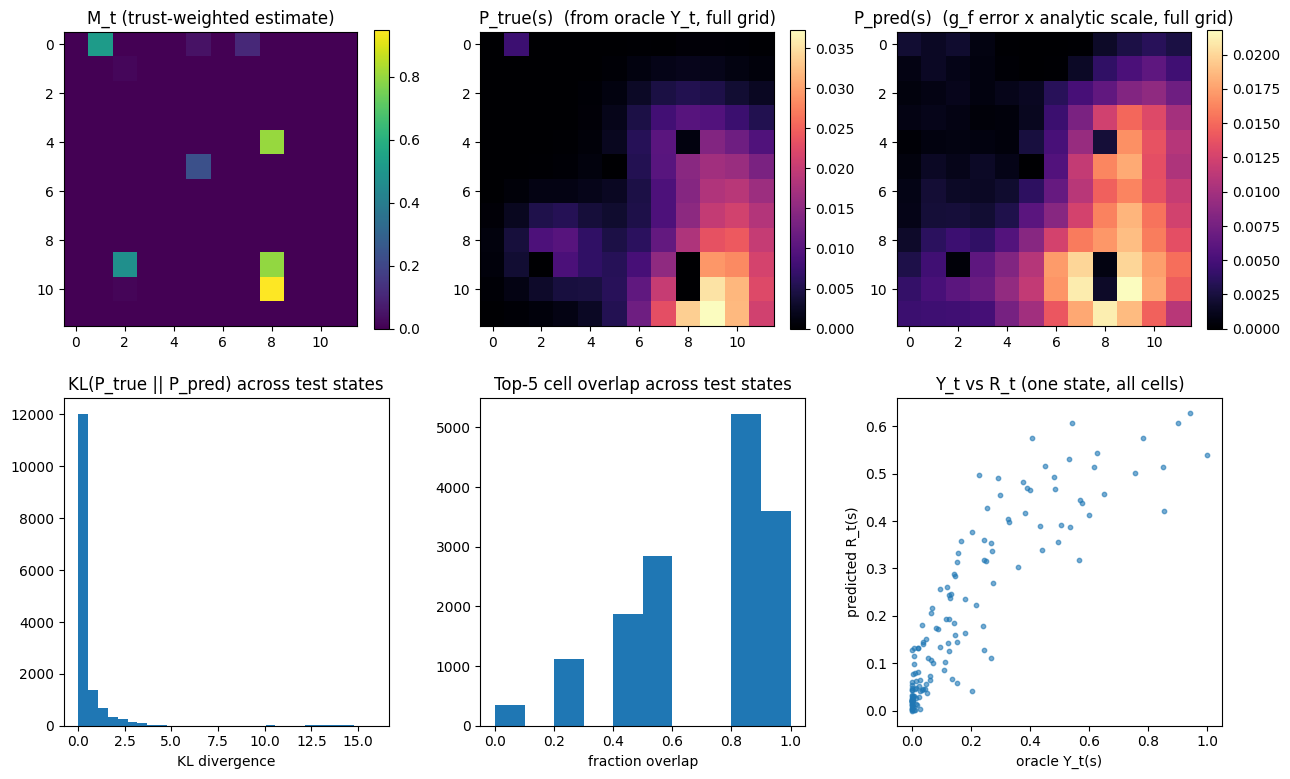

In [ ]:
ALPHA_EPISODES = 10000
G_DATA_EPISODES = 10000
G_MAX_EPOCHS = 200
EVAL_EPISODES = 100

print("=== training alpha_net ===")
alpha_net, alpha_loss = train_alpha_net(episodes=ALPHA_EPISODES)

print("\n=== generating g_f training data ===")
X, E = build_dataset(alpha_net, episodes=G_DATA_EPISODES)
print("dataset:", X.shape, E.shape, " E (error-energy) stats:",
      float(E.min()), float(E.max()), float(E.mean()))

print("\n=== training g_f (predicts error energy only, full grid, "
      "visited/unvisited loss-balanced) ===")
gnet, g_loss = train_gnet(X, E, max_epochs=G_MAX_EPOCHS)

print("\n=== validating g_f (Y_t reconstructed as e_pred^2 * scale(U), "
      "with visited/unvisited breakdown) ===")
kls, overlaps, sample = evaluate(gnet, alpha_net, episodes=EVAL_EPISODES)
plot_validation(kls, overlaps, sample)

torch.save(alpha_net.state_dict(), "alpha_net.pt")
torch.save(gnet.state_dict(), "gnet.pt")
print("\nsaved alpha_net.pt and gnet.pt")